In [1]:
import pandas as pd
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
automl = pd.read_csv("../results_download/automl_eval_results.csv")
automl.head()

,dataset,framework,few_shot,config,_runtime,accuracy,macro avg_f1-score,macro avg_precision,macro avg_recall,macro avg_support,weighted avg_f1-score,weighted avg_precision,weighted avg_recall,weighted avg_support
0,DeepPavlov/clinc150,fedot,full,"{'dataset': 'DeepPavlov/clinc150', 'framework'...",2188.463990,0.181818,0.002038,0.001204,0.006623,5500.0,0.055944,0.033058,0.181818,5500.0
1,DeepPavlov/clinc150,lama,full,"{'dataset': 'DeepPavlov/clinc150', 'framework'...",117.102701,0.181818,0.002038,0.001204,0.006623,5500.0,0.055944,0.033058,0.181818,5500.0
2,DeepPavlov/clinc150,h2o,full,"{'dataset': 'DeepPavlov/clinc150', 'framework'...",1238.132398,0.663091,0.712536,0.680751,0.766748,5500.0,0.638623,0.704187,0.663091,5500.0
3,DeepPavlov/clinc150,h2o,2,"{'dataset': 'DeepPavlov/clinc150', 'few_shot':...",1219.092810,0.042727,0.040263,0.047353,0.051876,5500.0,0.033162,0.039002,0.042727,5500.0
4,DeepPavlov/clinc150,h2o,4,"{'dataset': 'DeepPavlov/clinc150', 'few_shot':...",1207.263286,0.079636,0.078999,0.082079,0.094119,5500.0,0.069192,0.149002,0.079636,5500.0


In [20]:
automl = automl[automl["framework"].isin(["gluon", "h2o"]) & (automl["few_shot"] != '2')]
automl["few_shot"] = automl["few_shot"].fillna("full")

In [31]:
automl = automl.rename(columns={
    "macro avg_f1-score": "f1",
    # "accuracy": "accuracy",
    "macro avg_precision": "precision",
    "macro avg_recall": "recall",
})
automl = automl[["dataset", "framework", "few_shot", "f1", "precision", "recall", "accuracy"]]
automl

,dataset,framework,few_shot,f1,precision,recall,accuracy
2,DeepPavlov/clinc150,h2o,full,0.712536,0.680751,0.766748,0.663091
4,DeepPavlov/clinc150,h2o,4,0.078999,0.082079,0.094119,0.079636
5,DeepPavlov/clinc150,h2o,8,0.237940,0.243182,0.268845,0.226545
6,DeepPavlov/clinc150,h2o,16,0.444857,0.434060,0.484170,0.406364
7,DeepPavlov/clinc150,h2o,32,0.643760,0.620915,0.691974,0.585455
10,DeepPavlov/massive,h2o,full,0.701375,0.731363,0.696775,0.753032
12,DeepPavlov/massive,h2o,4,0.102474,0.123981,0.147428,0.104784
13,DeepPavlov/massive,h2o,8,0.116590,0.123169,0.165744,0.122305
14,DeepPavlov/massive,h2o,16,0.282221,0.288150,0.360564,0.282008
15,DeepPavlov/massive,h2o,32,NaN,NaN,NaN,NaN


In [22]:
autointent = pd.read_csv("../results_download/few_shot_results.csv")
autointent.head()

,dataset,few_shot,config,_runtime,configs,decision_accuracy,decision_f1,decision_precision,decision_recall,decision_roc_auc,metrics,pipeline_metrics
0,DeepPavlov/hwu64,4,"{'regex': [], 'scoring': [{'metrics': {'scorin...",1.034076,{'decision': [{'metric_name': 'decision_accura...,0.759294,0.749508,0.764930,0.766580,0.881379,"{'decision': [0.7476901208244492, 0.4048803601...","{'decision_accuracy': 0.7592936802973977, 'dec..."
1,DeepPavlov/hwu64,8,"{'regex': [], 'scoring': [{'metrics': {'scorin...",1.207324,{'decision': [{'metric_name': 'decision_accura...,0.815056,0.808742,0.813985,0.824376,0.910720,"{'decision': [0.7848675914249684, 0.7044136191...","{'decision_accuracy': 0.8150557620817844, 'dec..."
2,DeepPavlov/hwu64,16,"{'regex': [], 'scoring': [{'metrics': {'scorin...",1.182504,{'decision': [{'metric_name': 'decision_accura...,0.841078,0.836894,0.837447,0.850721,0.924099,"{'decision': [0.8330439814814815, 0.8038194444...","{'decision_accuracy': 0.8410780669144982, 'dec..."
3,DeepPavlov/hwu64,32,"{'regex': [], 'scoring': [{'metrics': {'scorin...",1.122662,{'decision': [{'metric_name': 'decision_accura...,0.861524,0.860324,0.861766,0.865239,0.931520,"{'decision': [0.8592802264456126, 0.8152042054...","{'decision_accuracy': 0.8615241635687733, 'dec..."
4,DeepPavlov/hwu64,64,"{'regex': [], 'scoring': [{'metrics': {'scorin...",1.151558,{'decision': [{'metric_name': 'decision_accura...,0.880112,0.878294,0.880205,0.883809,0.940952,"{'decision': [0.8872767857142857, 0.8638392857...","{'decision_accuracy': 0.8801115241635687, 'dec..."


In [23]:
autointent["dataset"].value_counts()

dataset
DeepPavlov/hwu64      7
DeepPavlov/minds14    7
DeepPavlov/snips      7
Name: count, dtype: int64

In [ ]:
autointent = autointent.rename(columns={
    "decision_accuracy": "accuracy",
    "decision_f1": "f1",
    "decision_precision": "precision",
    "decision_recall": "recall",
})
autointent = autointent[["dataset", "few_shot", "f1", "precision", "recall", "accuracy"]]
autointent

KeyError: "['framework'] not in index"

In [38]:
automl = automl[automl["dataset"].isin(autointent["dataset"].unique())]

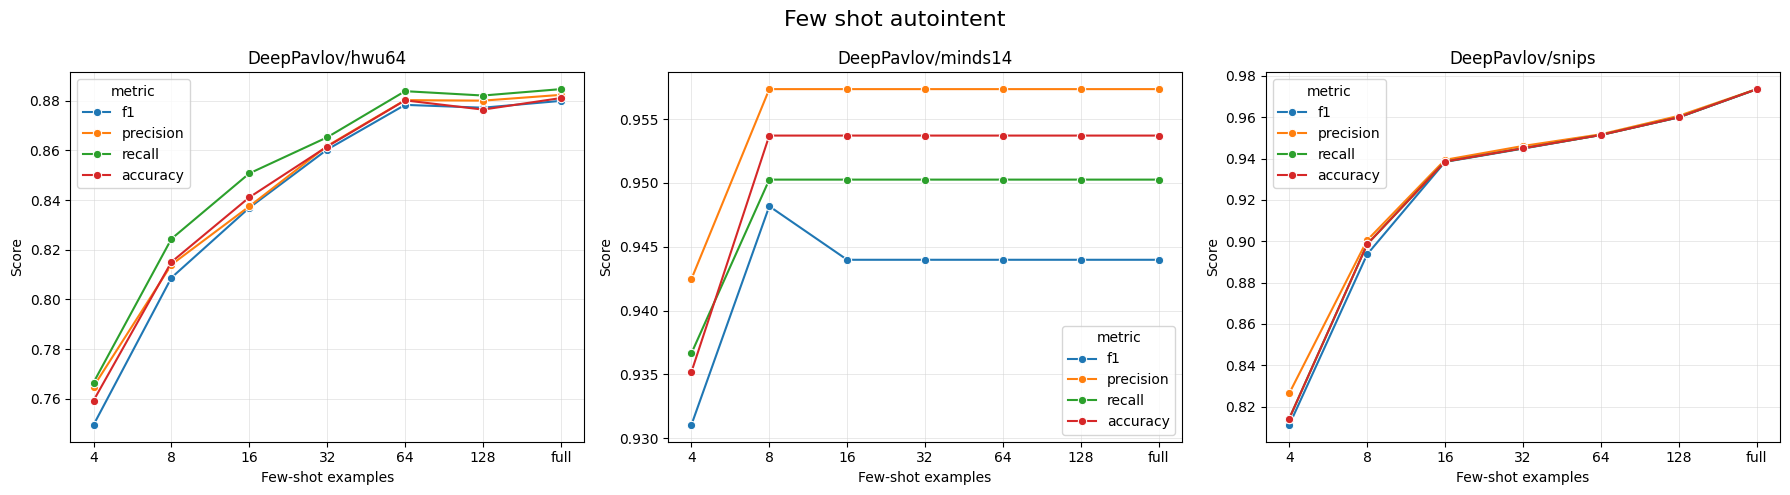

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data: drop 'full', cast few_shot to int
df_plot = autointent.copy()
df_plot.loc[df_plot['few_shot'] == 'full', 'few_shot'] = '256'
# df_plot = df_plot[df_plot['few_shot'] != '256']
df_plot['few_shot'] = df_plot['few_shot'].astype(int)

# Determine unique datasets
datasets = sorted(df_plot['dataset'].unique())
fig, axes = plt.subplots(1, len(datasets), figsize=(18, 5), sharey=False)

# Define few-shot ticks including 256
xticks = [4, 8, 16, 32, 64, 128, 256]
xticks_labels = [4, 8, 16, 32, 64, 128, 'full']

for ax, ds in zip(axes, datasets):
    sub = df_plot[df_plot['dataset'] == ds]
    sub_melt = sub.melt(
        id_vars='few_shot',
        value_vars=['f1', 'precision', 'recall', 'accuracy'],
        var_name='metric',
        value_name='score'
    )
    sns.lineplot(
        data=sub_melt,
        x='few_shot', y='score',
        hue='metric', marker='o', ax=ax
    )
    ax.set_xscale('log', base=2)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks_labels)
    ax.set_title(ds)
    ax.set_xlabel('Few‐shot examples')
    ax.set_ylabel('Score')
    ax.grid(True, color='lightgray', linewidth=0.5, alpha=0.7)


plt.suptitle("Few shot autointent", fontsize=16)
plt.savefig("autointent_few_shot.png", dpi=300)
plt.savefig("autointent_few_shot.svg")
fig.tight_layout()
plt.show()

In [33]:
automl

,dataset,framework,few_shot,f1,precision,recall,accuracy
2,DeepPavlov/clinc150,h2o,full,0.712536,0.680751,0.766748,0.663091
4,DeepPavlov/clinc150,h2o,4,0.078999,0.082079,0.094119,0.079636
5,DeepPavlov/clinc150,h2o,8,0.237940,0.243182,0.268845,0.226545
6,DeepPavlov/clinc150,h2o,16,0.444857,0.434060,0.484170,0.406364
7,DeepPavlov/clinc150,h2o,32,0.643760,0.620915,0.691974,0.585455
10,DeepPavlov/massive,h2o,full,0.701375,0.731363,0.696775,0.753032
12,DeepPavlov/massive,h2o,4,0.102474,0.123981,0.147428,0.104784
13,DeepPavlov/massive,h2o,8,0.116590,0.123169,0.165744,0.122305
14,DeepPavlov/massive,h2o,16,0.282221,0.288150,0.360564,0.282008
15,DeepPavlov/massive,h2o,32,NaN,NaN,NaN,NaN


In [40]:
frameworks

['gluon', 'h2o']

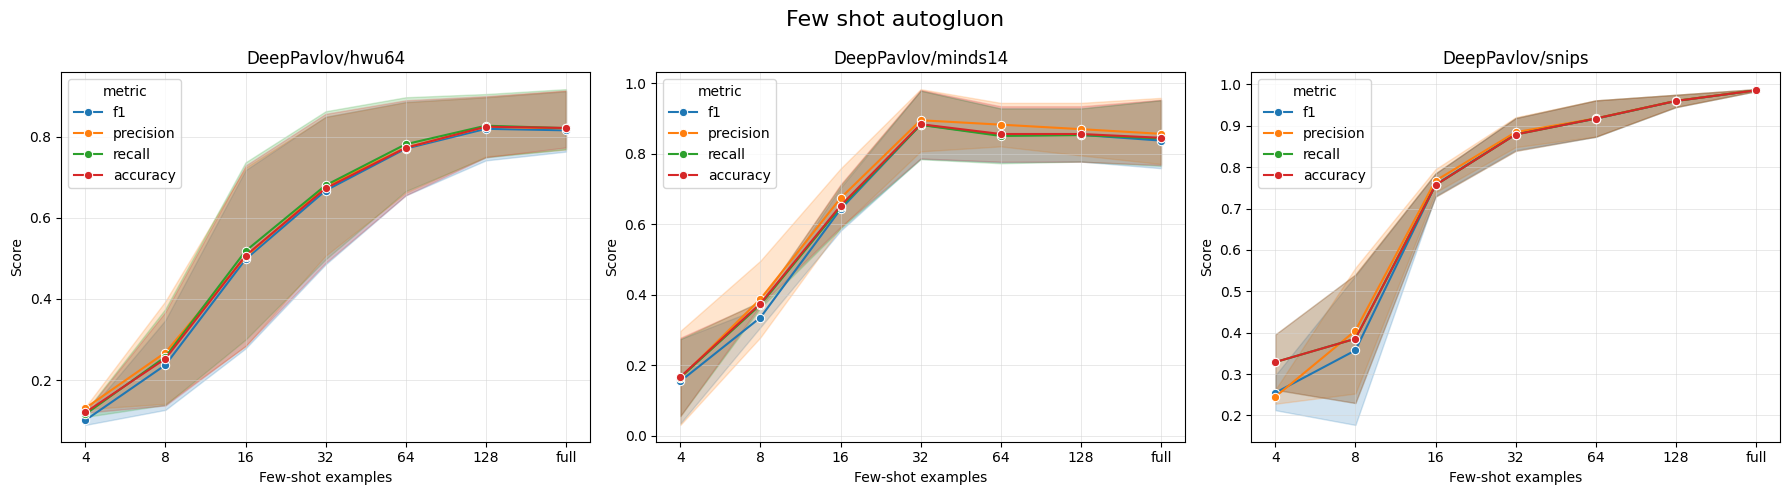

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data: drop 'full', cast few_shot to int
df_plot = automl.copy()
df_plot.loc[df_plot['few_shot'] == 'full', 'few_shot'] = '256'
# df_plot = df_plot[df_plot['few_shot'] != '256']
df_plot['few_shot'] = df_plot['few_shot'].astype(float).astype(int)

# Determine unique datasets
datasets = sorted(df_plot['dataset'].unique())
frameworks = sorted(df_plot['framework'].unique())
fig, axes = plt.subplots(1, len(datasets), figsize=(18, 5), sharey=False)

# Define few-shot ticks including 256
xticks = [4, 8, 16, 32, 64, 128, 256]
xticks_labels = [4, 8, 16, 32, 64, 128, 'full']

for ax, ds in zip(axes, datasets):
    sub = df_plot[df_plot['dataset'] == ds]
    sub_melt = sub.melt(
        id_vars='few_shot',
        value_vars=['f1', 'precision', 'recall', 'accuracy'],
        var_name='metric',
        value_name='score'
    )
    sns.lineplot(
        data=sub_melt,
        x='few_shot', y='score',
        hue='metric', marker='o', ax=ax
    )
    ax.set_xscale('log', base=2)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks_labels)
    ax.set_title(ds)
    ax.set_xlabel('Few‐shot examples')
    ax.set_ylabel('Score')
    ax.grid(True, color='lightgray', linewidth=0.5, alpha=0.7)


plt.suptitle("Few shot autogluon", fontsize=16)
plt.savefig("autogluon_few_shot.png", dpi=300)
plt.savefig("autogluon_few_shot.svg")
fig.tight_layout()
plt.show()

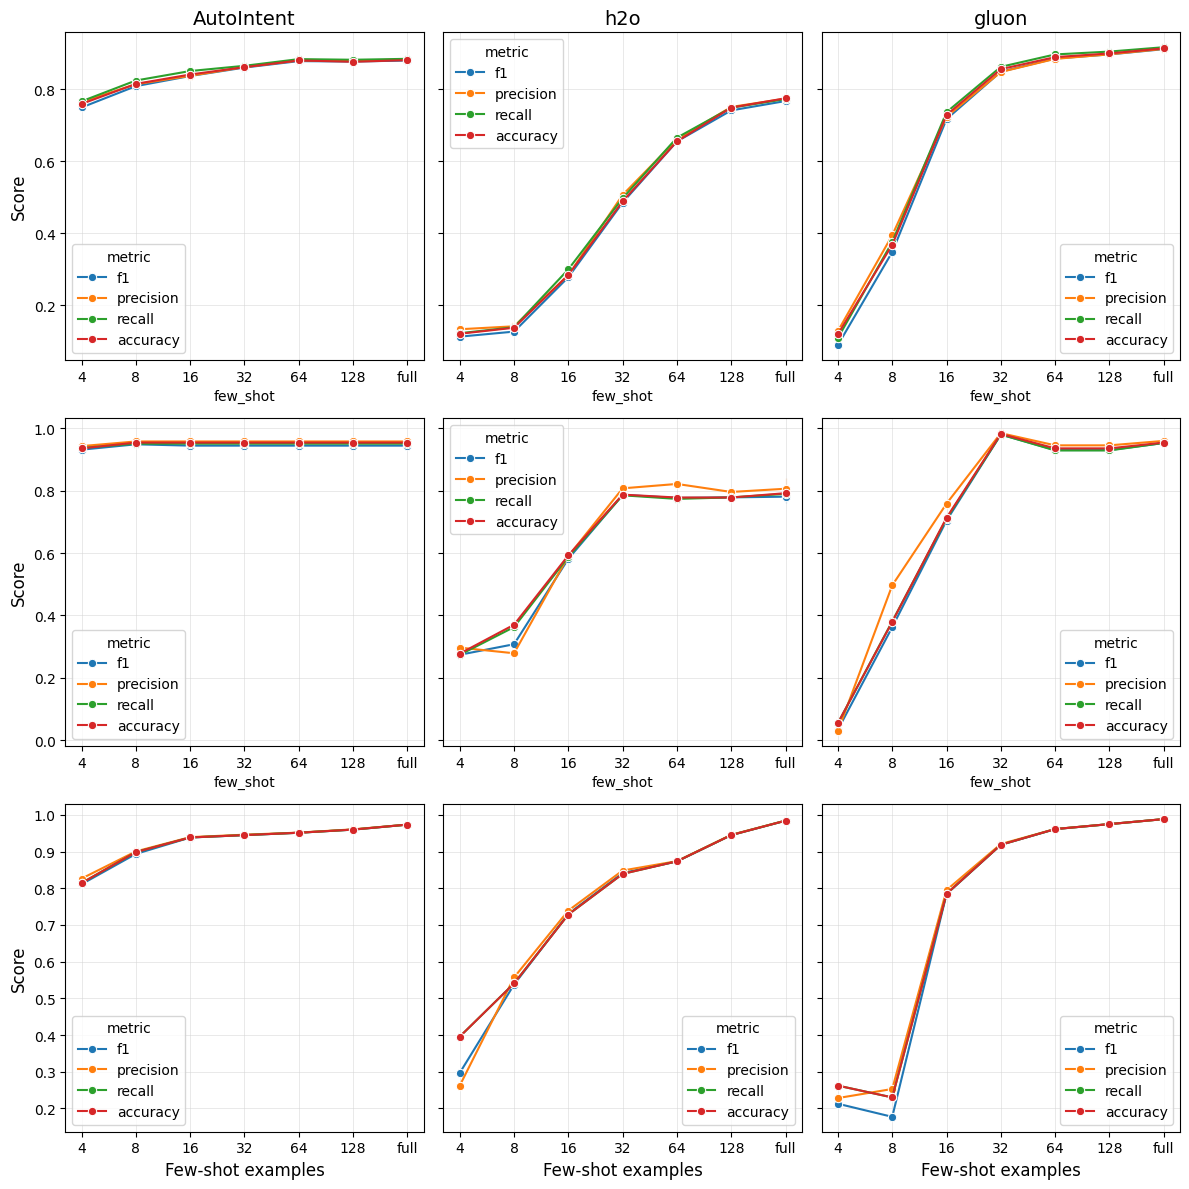

In [41]:
# Compare AutoIntent vs AutoGluon across datasets in a 3×2 grid
df_ai = autointent.copy()
df_ai.loc[df_ai['few_shot']=='full', 'few_shot'] = '256'
df_ai['few_shot'] = df_ai['few_shot'].astype(int)

# Prepare AutoGluon data
df_ml = automl.copy()
df_ml.loc[df_ml['few_shot']=='full', 'few_shot'] = '256'
df_ml['few_shot'] = df_ml['few_shot'].astype(float).astype(int)


# Common settings
datasets = sorted(df_ai['dataset'].unique())
frameworks = [("AutoIntent", df_ai)]
for fw in df_ml['framework'].unique():
    frameworks.append((fw, df_ml[df_ml['framework'] == fw]))

xticks = [4, 8, 16, 32, 64, 128, 256]
xticks_labels = [4, 8, 16, 32, 64, 128, "full"]

# Create a 3 rows × 2 cols grid
fig, axes = plt.subplots(len(datasets), len(frameworks),
                         figsize=(12, 12), sharey='row')

for i, ds in enumerate(datasets):
    for j, (label, df) in enumerate(frameworks):
        ax = axes[i, j]
        sub = df[df['dataset']==ds]
        sub_melt = sub.melt(
            id_vars='few_shot',
            value_vars=['f1','precision','recall','accuracy'],
            var_name='metric',
            value_name='score'
        )
        sns.lineplot(
            data=sub_melt, x='few_shot', y='score',
            hue='metric', marker='o', ax=ax
        )
        ax.set_xscale('log', base=2)
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticks_labels)
        ax.grid(True, color='lightgray', linewidth=0.5, alpha=0.7)
        if i==0:
            ax.set_title(label, fontsize=14)
        if j==0:
            ax.set_ylabel('Score', fontsize=12)
        if i==len(datasets)-1:
            ax.set_xlabel('Few-shot examples', fontsize=12)

plt.tight_layout()
plt.savefig("comparison_few_shot.png", dpi=300)
plt.savefig("comparison_few_shot.svg")
plt.show()

H2O
AutoGluon


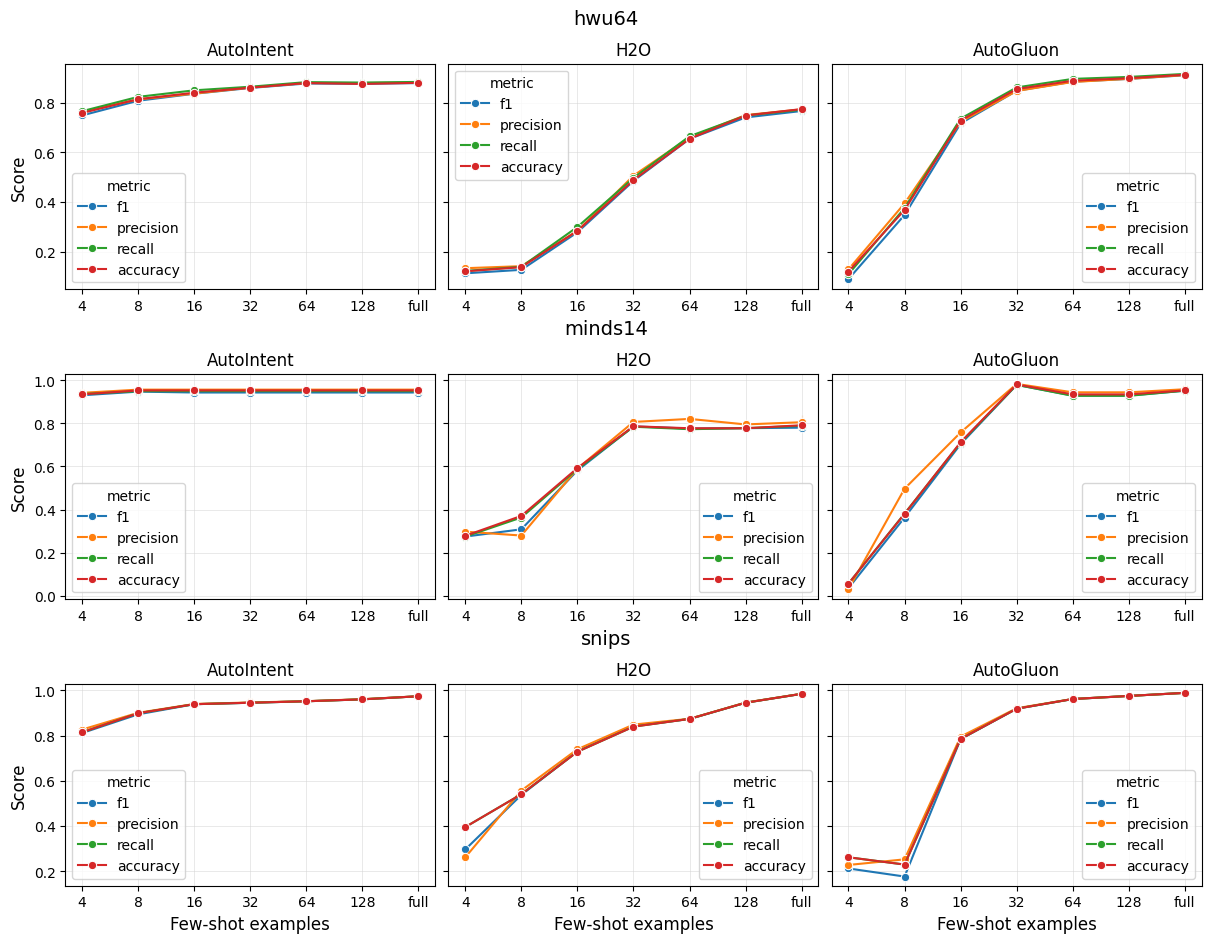

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Tuple


def plot_comparison_few_shot(
    autointent: pd.DataFrame,
    automl: pd.DataFrame
) -> None:
    """
    Generate a comparison plot of AutoIntent vs AutoGluon over few-shot sizes
    using Matplotlib SubFigures for per-row grouping.
    """
    # Prepare AutoIntent data
    df_ai = autointent.copy()
    df_ai.loc[df_ai['few_shot'] == 'full', 'few_shot'] = '256'
    df_ai['few_shot'] = df_ai['few_shot'].astype(int)

    # Prepare AutoGluon data
    df_ag = automl.copy()
    df_ag.loc[df_ag['few_shot'] == 'full', 'few_shot'] = '256'
    df_ag['few_shot'] = df_ag['few_shot'].astype(float).astype(int)
    df_ag.loc[df_ag['framework'] == 'gluon', 'framework'] = 'AutoGluon'
    df_ag.loc[df_ag['framework'] == 'h2o', 'framework'] = 'H2O'

    # Settings
    datasets = sorted(df_ai['dataset'].unique())
    frameworks = [("AutoIntent", df_ai)]
    for fw in df_ag['framework'].unique():
        frameworks.append((fw, df_ag[df_ag['framework'] == fw]))
        print(fw)

    xticks = [4, 8, 16, 32, 64, 128, 256]
    xticks_labels = [4, 8, 16, 32, 64, 128, 'full']

    # Create main figure
    n_rows = len(datasets)
    fig = plt.figure(constrained_layout=True, figsize=(12, 3 * n_rows))

    # Create SubFigures: one per dataset row
    subfigs = fig.subfigures(n_rows, 1, hspace=0.1)

    for i, (ds, subfig) in enumerate(zip(datasets, subfigs)):
        # Add a row label as subfigure title
        subfig.suptitle(ds.replace("DeepPavlov/", ""), fontsize=14, y=1.1)

        # Create two side-by-side axes in each subfigure
        axs = subfig.subplots(1, len(frameworks), sharey='all')
        for j, (ax, (label, df)) in enumerate(zip(axs, frameworks)):
            # Melt and plot
            subset = df[df['dataset'] == ds]
            melted = subset.melt(
                id_vars='few_shot',
                value_vars=['f1', 'precision', 'recall', 'accuracy'],
                var_name='metric',
                value_name='score'
            )
            sns.lineplot(
                data=melted,
                x='few_shot', y='score',
                hue='metric', marker='o', ax=ax
            )
            ax.set_xscale('log', base=2)
            ax.set_xticks(xticks)
            ax.set_xticklabels(xticks_labels)
            ax.set_xlabel(None)
            ax.grid(True, color='lightgray', linewidth=0.5, alpha=0.7)
            ax.set_title(label, fontsize=12)
            # only the left column gets y-label
            if j == 0:
                ax.set_ylabel('Score', fontsize=12)
            # only bottom row gets x-labels
            if i == n_rows - 1:
                ax.set_xlabel('Few-shot examples', fontsize=12)

    # Save and show
    plt.savefig("comparison_few_shot_subfigures.png", dpi=300)
    plt.savefig("comparison_few_shot_subfigures.svg", bbox_inches="tight")
    plt.show()

plot_comparison_few_shot(autointent, automl)


In [49]:
df_ai = autointent.copy()
# df_ai.loc[df_ai['few_shot'] == 'full', 'few_shot'] = '256'
# df_ai['few_shot'] = df_ai['few_shot'].astype(int)

# Prepare AutoGluon data
df_ag = automl.copy()
# df_ag.loc[df_ag['few_shot'].isna(), 'few_shot'] = '256'
# df_ag['few_shot'] = df_ag['few_shot'].astype(float).astype(int)



In [52]:
df_ai["framework"] = "AutoIntent"

In [53]:
df_ag.loc[df_ag['framework'] == 'gluon', 'framework'] = 'AutoGluon'
df_ag.loc[df_ag['framework'] == 'h2o', 'framework'] = 'H2O'


In [56]:
pd.concat([df_ai, df_ag]).reset_index(drop=True).sort_values(by=["dataset", "framework", "few_shot"]).to_csv("comparison_few_shot.csv", index=False)